# Homework 4 — Hints: Quantum Phase Estimation & Shor's Algorithm
**Notebook:** Guided hints for implementing QFT-based phase estimation

## Overview

This notebook provides **hints and partial implementations** for Homework 4,
which covers the **Quantum Fourier Transform** and its application in
**quantum phase estimation** — the core subroutine of Shor's factoring algorithm.

### Quantum Phase Estimation (QPE)
Given a unitary $U$ with eigenvector $|u\rangle$ and eigenvalue $e^{2\pi i \phi}$,
QPE estimates the phase $\phi$ to $n$ bits of precision using $n$ ancilla qubits and
one application of controlled-$U^{2^k}$ for $k = 0, \ldots, n-1$.

**Circuit structure:**
1. Hadamard on all ancilla qubits
2. Controlled-$U^{2^k}$ operations
3. Inverse QFT on ancilla register
4. Measure ancilla → read off $\phi$

### Key component: QFT†
The **inverse QFT** (QFT-dagger) circuit is the QFT run in reverse with conjugated phase gates:
$$R_k^\dagger = \begin{pmatrix}1&0\\0&e^{-2\pi i/2^k}\end{pmatrix}$$

### Homework 4 -hint for the Shor' algorithm

<b> Problem 2: Shor' algorith in qiskit </b>

 Design the quantum circuit which can find periods for the modular exponent $a^x (mod N)$ with some small number $a$ and $N$, e.g. $a=3$, $N=10$ or $a=2$, $N=9$. Test the algorithm using qiskit.
 
 <br />

  
<b> Solution </b>
We will use similar approach as in Qiskit tutorial https://qiskit.org/textbook/ch-algorithms/shor.html. 
The key components is the realization of modular exponent $a^x (mod N)$ using qunatum operators. 


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from math import gcd
from numpy.random import randint
import pandas as pd
from fractions import Fraction

backend = AerSimulator()

Let's investigate the period $a^r mod N =1$ analytically

Could not find period, check a < N and have no common factors.


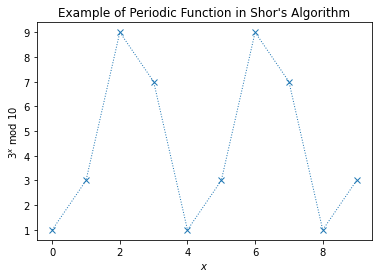

In [63]:
N = 10
a = 3

# Calculate the plotting data
xvals = np.arange(10)
yvals = [np.mod(a**x, N) for x in xvals]

# Use matplotlib to display it nicely
fig, ax = plt.subplots()
ax.plot(xvals, yvals, linewidth=1, linestyle='dotted', marker='x')
ax.set(xlabel='$x$', ylabel='$%i^x$ mod $%i$' % (a, N),
       title="Example of Periodic Function in Shor's Algorithm")
try: # plot r on the graph
    r = yvals[1:].index(1) +1 
    plt.annotate(text='', xy=(0,1), xytext=(r,1), arrowprops=dict(arrowstyle='<->'))
    plt.annotate(text='$r=%i$' % r, xy=(r/3,1.5))
except:
    print('Could not find period, check a < N and have no common factors.')

def qft_dagger(n):
    """n-qubit inverse QFT on the first n qubits.

    The inverse QFT (QFT†) is the adjoint of the QFT. It is built by:
      1. Bit-reversal permutation: swap qubit i with qubit (n-1-i)
         so the output register ends up in the correct order.
      2. For each qubit j, apply controlled-phase rotations with
         negative angles (conjugating the forward QFT rotations),
         then apply a Hadamard to complete that qubit's contribution.
    The result undoes the QFT, mapping frequency-domain states back
    to computational-basis states encoding the measured phase.
    """
    qc = QuantumCircuit(n)

    # Step 1: bit-reversal — swap pairs of qubits to reverse register order
    for qubit in range(n // 2):
        qc.swap(qubit, n - qubit - 1)

    # Step 2: apply inverse phase rotations and Hadamards qubit by qubit
    for j in range(n):
        # For each earlier qubit m, apply controlled-R†_{j-m}:
        # angle = -pi / 2^(j-m), which negates the forward QFT phase
        for m in range(j):
            qc.cp(-np.pi / float(2 ** (j - m)), m, j)
        # Hadamard collapses the superposition for this qubit
        qc.h(j)

    qc.name = "QFT†"
    return qc

In [ ]:
def qft_dagger(n):
    """n-qubit inverse QFT on the first n qubits."""
    qc = QuantumCircuit(n)
    for qubit in range(n // 2):
        qc.swap(qubit, n - qubit - 1)
    for j in range(n):
        for m in range(j):
            qc.cp(-np.pi / float(2 ** (j - m)), m, j)
        qc.h(j)
    qc.name = "QFT†"
    return qc

def U2():
    """Controlled-U^2 gate: implements multiplication by 9 mod 10.

    Since 3^2 = 9 mod 10, applying U twice maps |1> -> |9 mod 10> = |1001>.
    Starting from |0001> (i.e., |1>), U^2|1> = |9> means qubit 3 flips (X on index 3).
    The gate is wrapped as a controlled gate for use in QPE.
    """
    U = QuantumCircuit(4)
    U.x(3)          # flip qubit 3: encodes 9 mod 10 = 1001 in binary
    U = U.to_gate()
    U.name = "U2"
    c_U = U.control()  # make it a controlled gate for QPE
    return c_U

In [ ]:
def U1():
    """Controlled-U^1 gate: implements multiplication by 3 mod 10.

    U_3 maps: |0001> -> |0011> (1 -> 3) and |1001> -> |0111> (9 -> 7).
    Inspecting the binary action:
      - X on qubit 1 flips bit 1 (handles the common X_1 component)
      - SWAP(3, 2) exchanges the upper two bits (handles the permutation component)
    Together these two operations reproduce U_3 on the relevant input subspace.
    Order matters here: these gates do NOT commute in general.
    """
    U = QuantumCircuit(4)
    U.x(1)          # flip qubit 1: part of the 3 mod 10 mapping
    U.swap(3, 2)    # swap qubits 2 and 3: completes the modular multiplication
    U = U.to_gate()
    U.name = "U1"
    c_U = U.control()  # make it a controlled gate for QPE
    return c_U

In [41]:
def U1():
    """Controlled multiplication by 9 mod 10"""
    U = QuantumCircuit(4)   
    U.x(1)
    U.swap(3,2)
    U = U.to_gate()
    U.name = "U1" 
    c_U = U.control()
    return c_U

In [65]:
# Create QuantumCircuit with n_count=3 counting qubits
# plus 4 qubits for U to act on
## Paste your code here (modify the qiskit textbook example accordingly) to get the following output

┌───┐              ┌───────┐┌─┐      
q_0: ┤ H ├──────────────┤0      ├┤M├──────
     ├───┤              │       │└╥┘┌─┐   
q_1: ┤ H ├───■──────────┤1 QFT† ├─╫─┤M├───
     ├───┤   │          │       │ ║ └╥┘┌─┐
q_2: ┤ H ├───┼──────■───┤2      ├─╫──╫─┤M├
     └───┘┌─┴┼──┐┌─┴┼──┐└───────┘ ║  ║ └╥┘
q_3: ─────┤0 │  ├┤0 │  ├──────────╫──╫──╫─
          │     ││     │          ║  ║  ║ 
q_4: ─────┤1    ├┤1    ├──────────╫──╫──╫─
          │  U2 ││  U1 │          ║  ║  ║ 
q_5: ─────┤2    ├┤2    ├──────────╫──╫──╫─
     ┌───┐│     ││     │          ║  ║  ║ 
q_6: ┤ X ├┤3    ├┤3    ├──────────╫──╫──╫─
     └───┘└─────┘└─────┘          ║  ║  ║ 
c: 3/═════════════════════════════╩══╩══╩═
                                  0  1  2

In [ ]:
backend = AerSimulator()
results = backend.run(transpile(qc, backend), shots=2048).result()
counts = results.get_counts()
plot_histogram(counts)

rows, measured_phases = [], []
for output in counts:
    # Convert the binary measurement string to a decimal integer
    decimal = int(output, 2)
    # Divide by 2^n_count to get the estimated phase phi in [0, 1)
    # QPE encodes phi as the integer k where k/2^n ~ phi
    phase = decimal/(2**n_count)
    measured_phases.append(phase)
    # Record both representations for the results table
    rows.append(["%s(bin) = %i(dec)" % (output, decimal),
                 "%i/%i = %.2f" % (decimal, 2**n_count, phase)])
# Print the rows in a table
headers=["Register Output", "Phase"]
df = pd.DataFrame(rows, columns=headers)
print(df)

In [ ]:
rows = []
for phase in measured_phases:
    # Use continued-fraction expansion to find the best rational approximation
    # to the measured phase with denominator <= 15.
    # The denominator of phi = s/r gives a candidate for the period r.
    frac = Fraction(phase).limit_denominator(15)
    rows.append([phase, "%i/%i" % (frac.numerator, frac.denominator), frac.denominator])
# Print as a table
headers=["Phase", "Fraction", "Guess for r"]
df = pd.DataFrame(rows, columns=headers)
print(df)

In [57]:
rows = []
for phase in measured_phases:
    frac = Fraction(phase).limit_denominator(15)
    rows.append([phase, "%i/%i" % (frac.numerator, frac.denominator), frac.denominator])
# Print as a table
headers=["Phase", "Fraction", "Guess for r"]
df = pd.DataFrame(rows, columns=headers)
print(df)

   Phase Fraction  Guess for r
0  0.000      0/1            1
1  0.125      1/8            8
2  0.250      1/4            4
3  0.375      3/8            8
4  0.625      5/8            8
5  0.750      3/4            4
6  0.875      7/8            8


Comparing with the above plot one can see that the procedure works. 